# Smart Player Crop Pipeline for Logo Annotation
## Bradford Bulls — AI Sponsorship Exposure Valuation

### Key insight: Annotate on **player crops**, not full frames
- Full frame: logo = 1-3% of image → hard to detect/annotate
- Player crop: logo = 10-20% of image → easy to detect/annotate

### 6-Layer Pipeline
```
L1  Temporal sample (1 FPS)          162,000 → 5,400 frames
L2  Person detect + crop (YOLOv8)    5,400 → ~20,000 player crops
L3  Team filter (jersey color)       20,000 → ~10,000 (Bradford only)
L4  Quality scoring (size+sharp+pose) 10,000 → ~3,000
L5  De-duplicate (pHash on crops)     3,000 → ~800
L6  Top N selection with diversity    800 → 200-400 final crops
```

> Runs on **Google Colab GPU**. All data stored on **Google Drive**.
> **IMPORTANT**: After Cell 1 (installs), **restart runtime** before running Cell 2+.

## 1. Install ALL Dependencies
> **Run this cell first, then restart runtime** (Runtime → Restart runtime).
> This avoids version conflicts between packages.

In [1]:
# ============================================================
# ALL PACKAGE INSTALLS — Run once, then restart runtime
# ============================================================

# Force-remove packages that cause conflicts FIRST
!pip uninstall -y autodistill autodistill-grounding-dino sentence-transformers 2>/dev/null || true

# Core ML + CV
!pip install -q ultralytics yt-dlp imagehash scikit-image scikit-learn pillow opencv-python-headless

# Roboflow upload
!pip install -q roboflow

# Grounding DINO (direct, NO autodistill)
!pip install -q transformers==4.37.2
!pip install -q groundingdino-py

# Download Grounding DINO model weights + config
import os
GDINO_CACHE = "/content/gdino_cache"
os.makedirs(GDINO_CACHE, exist_ok=True)

CONFIG_URL = "https://raw.githubusercontent.com/IDEA-Research/GroundingDINO/main/groundingdino/config/GroundingDINO_SwinT_OGC.py"
WEIGHTS_URL = "https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth"

GDINO_CONFIG_PATH = f"{GDINO_CACHE}/GroundingDINO_SwinT_OGC.py"
GDINO_WEIGHTS_PATH = f"{GDINO_CACHE}/groundingdino_swint_ogc.pth"

if not os.path.exists(GDINO_CONFIG_PATH):
    !wget -q -O {GDINO_CONFIG_PATH} {CONFIG_URL}
    print(f"Downloaded config: {GDINO_CONFIG_PATH}")
else:
    print(f"Config exists: {GDINO_CONFIG_PATH}")

if not os.path.exists(GDINO_WEIGHTS_PATH):
    !wget -q --show-progress -O {GDINO_WEIGHTS_PATH} {WEIGHTS_URL}
    print(f"Downloaded weights: {GDINO_WEIGHTS_PATH}")
else:
    print(f"Weights exist: {GDINO_WEIGHTS_PATH}")

# Quick sanity check
try:
    from groundingdino.util.inference import load_model
    print("\n✅ groundingdino import OK")
except ImportError as e:
    print(f"\n❌ groundingdino import failed: {e}")

print("\n⚠️ NOW RESTART RUNTIME (Runtime → Restart runtime) before running next cell!")

Found existing installation: sentence-transformers 5.3.0
Uninstalling sentence-transformers-5.3.0:
  Successfully uninstalled sentence-transformers-5.3.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 144.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 9

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


## 2. Configuration
> **⚠️ TEST MODE**: Small values are set by default so you can verify the pipeline works.
> Once everything runs clean, change to **PRODUCTION** values (commented below).

In [2]:
# ============================================================
# ⚠️ MASTER CONFIG — Change values here, not in other cells
# ============================================================

# --- VIDEO ---
VIDEO_URL = "https://www.youtube.com/watch?v=VjjO9Zmhdhk"

# --- SAMPLING ---
TARGET_FPS = 1              # Frames per second to sample

# --- DETECTION ---
YOLO_BATCH = 16             # GPU batch size (lower to 8 if OOM)
MIN_PLAYER_HEIGHT = 120     # Min crop height in pixels
MIN_AREA_RATIO = 0.015      # Min player area as % of frame (1.5%)
CROP_PADDING = 0.05         # 5% padding around bbox

# --- SELECTION ---
MIN_QUALITY = 0.25          # L4: min quality score
DEDUP_HASH_THRESH = 8       # L5: min pHash distance for de-dup
TIME_BUCKET_SEC = 30        # L6: time diversity bucket (seconds)

# --- GROUNDING DINO ---
GDINO_BOX_THRESHOLD = 0.15  # Detection confidence threshold
GDINO_TEXT_THRESHOLD = 0.15 # Text matching threshold

# --- ROBOFLOW ---
ROBOFLOW_API_KEY = "Z7jfikrrq6dgA0YGrPua"  # ← Replace with your key
PROJECT_NAME = "kit-sponsor-logos"

# ============================================================
# ⚠️ TEST vs PRODUCTION — Toggle this flag
# ============================================================
TEST_MODE = True  # ← Set to False for full production run

if TEST_MODE:
    MAX_FRAMES_TO_PROCESS = 500    # Only process first 500 frames (~17s)
    TARGET_CROPS = 10              # Select only 10 crops
    print("🧪 TEST MODE: Processing only 500 frames, selecting 10 crops")
    print("   Set TEST_MODE = False for full production run")
else:
    MAX_FRAMES_TO_PROCESS = None   # Process entire video
    TARGET_CROPS = 300             # 200-400 is sweet spot
    print("🚀 PRODUCTION MODE: Processing full video, selecting 300 crops")

print(f"\nTarget FPS: {TARGET_FPS}")
print(f"YOLO batch: {YOLO_BATCH}")
print(f"Target crops: {TARGET_CROPS}")

🧪 TEST MODE: Processing only 500 frames, selecting 10 crops
   Set TEST_MODE = False for full production run

Target FPS: 1
YOLO batch: 16
Target crops: 10


## 3. Setup (imports, GPU, Drive, paths)

In [3]:
import torch

# GPU check
device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("⚠️ No GPU! Go to Runtime → Change runtime type → GPU")

# Drive mount
from google.colab import drive
drive.mount("/content/drive")

# Imports
import os, shutil, csv
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import imagehash
from PIL import Image
from tqdm import tqdm
from sklearn.cluster import KMeans
from ultralytics import YOLO

# Verify Grounding DINO import works (catches broken installs early)
from groundingdino.util.inference import load_model, load_image, predict
print("✅ Grounding DINO import OK")

# ============================================================
# ALL PATHS ON GOOGLE DRIVE
# ============================================================
DRIVE_ROOT = Path("/content/drive/MyDrive/Bradford_Bulls")

VIDEOS_DIR      = DRIVE_ROOT / "videos"
CROPS_DIR       = DRIVE_ROOT / "player_crops"
BEST_CROPS_DIR  = DRIVE_ROOT / "best_crops"
METADATA_DIR    = DRIVE_ROOT / "metadata"
AUTOLABEL_DIR   = DRIVE_ROOT / "auto_annotated_crops"

for d in [VIDEOS_DIR, CROPS_DIR, BEST_CROPS_DIR, METADATA_DIR, AUTOLABEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("\nAll data on Google Drive:")
for d in [VIDEOS_DIR, CROPS_DIR, BEST_CROPS_DIR, METADATA_DIR, AUTOLABEL_DIR]:
    print(f"  {d}")

GPU: Tesla T4 | VRAM: 15.6 GB
Mounted at /content/drive
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Grounding DINO import OK

All data on Google Drive:
  /content/drive/MyDrive/Bradford_Bulls/videos
  /content/drive/MyDrive/Bradford_Bulls/player_crops
  /content/drive/MyDrive/Bradford_Bulls/best_crops
  /content/drive/MyDrive/Bradford_Bulls/metadata
  /content/drive/MyDrive/Bradford_Bulls/auto_annotated_crops


## 4. Download / Load Video

In [4]:
existing = sorted(VIDEOS_DIR.glob("*.mp4"), key=lambda f: f.stat().st_mtime, reverse=True)
if existing:
    VIDEO_PATH = existing[0]
    print(f"Found existing video on Drive: {VIDEO_PATH.name}")
    print("Skipping download. Delete the file to re-download.")
else:
    print("Downloading video to Google Drive...")
    !yt-dlp -f "bestvideo[height<=1080]+bestaudio/best[height<=1080]/best" \
            --merge-output-format mp4 \
            -o "{VIDEOS_DIR}/%(title)s.%(ext)s" \
            --no-playlist "{VIDEO_URL}"
    VIDEO_PATH = sorted(VIDEOS_DIR.glob("*.mp4"), key=lambda f: f.stat().st_mtime, reverse=True)[0]

# Video metadata
cap = cv2.VideoCapture(str(VIDEO_PATH))
FPS = cap.get(cv2.CAP_PROP_FPS)
TOTAL_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
DURATION = TOTAL_FRAMES / FPS
cap.release()

frame_interval = max(1, int(FPS / TARGET_FPS))

print(f"\n{VIDEO_PATH.name}")
print(f"{DURATION/60:.1f} min | {W}x{H} | {FPS:.0f} FPS | {TOTAL_FRAMES:,} frames")
print(f"Sampling every {frame_interval} frames ({TARGET_FPS} FPS)")

if TEST_MODE and MAX_FRAMES_TO_PROCESS:
    print(f"\n🧪 TEST: Will stop after {MAX_FRAMES_TO_PROCESS} frames")

Found existing video on Drive: output.mp4
Skipping download. Delete the file to re-download.

output.mp4
8.0 min | 1280x720 | 30 FPS | 14,400 frames
Sampling every 30 frames (1 FPS)

🧪 TEST: Will stop after 500 frames


## 5. Helper Functions

In [5]:
def get_jersey_region(crop):
    """Extract jersey region: skip top 15% (head) and bottom 40% (legs)."""
    h, w = crop.shape[:2]
    y1 = int(h * 0.15)
    y2 = int(h * 0.60)
    return crop[y1:y2, :]


def compute_sharpness(image):
    """Multi-metric sharpness score for a region."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    if gray.size == 0:
        return 0.0

    lap = cv2.Laplacian(gray, cv2.CV_64F).var()
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    ten = np.mean(gx**2 + gy**2)
    mean = gray.mean()
    nvar = gray.var() / (mean + 1e-6)

    score = (
        min(lap / 300.0, 1.0)  * 0.40 +
        min(ten / 5000.0, 1.0) * 0.35 +
        min(nvar / 50.0, 1.0)  * 0.25
    )
    return score


def compute_frontality(bbox_w, bbox_h):
    """Estimate front-facing from aspect ratio."""
    if bbox_w == 0:
        return 0.0
    aspect = bbox_h / bbox_w
    if aspect >= 2.5:
        return 1.0
    elif aspect >= 1.8:
        return 0.7
    elif aspect >= 1.3:
        return 0.4
    else:
        return 0.2


def get_dominant_colors(image, k=3):
    """Extract k dominant colors using K-means."""
    pixels = image.reshape(-1, 3).astype(np.float32)
    if len(pixels) < k:
        return pixels[:1]
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
    _, labels, centers = cv2.kmeans(pixels, k, None, criteria, 3, cv2.KMEANS_PP_CENTERS)
    counts = np.bincount(labels.flatten())
    order = np.argsort(-counts)
    return centers[order].astype(np.uint8)


def fmt_ts(sec):
    """Format seconds to HH:MM:SS string."""
    h = int(sec // 3600)
    m = int((sec % 3600) // 60)
    s = int(sec % 60)
    return f"{h:02d}h{m:02d}m{s:02d}s" if h > 0 else f"{m:02d}m{s:02d}s"

print("Helper functions loaded.")

Helper functions loaded.


## 6. [L1+L2] Temporal Sampling + Person Detection + Crop

Sample at 1 FPS → detect all persons with YOLOv8 (GPU batch) → crop each player.
Crops are NOT saved yet — only metadata + jersey colors collected.

In [6]:
model = YOLO("yolov8m.pt")
print(f"Model: yolov8m.pt | Batch: {YOLO_BATCH}")

cap = cv2.VideoCapture(str(VIDEO_PATH))
frame_area = W * H

all_crops_meta = []
jersey_colors = []
crop_id = 0

batch_frames = []
batch_frame_nums = []

frames_to_process = MAX_FRAMES_TO_PROCESS if TEST_MODE else TOTAL_FRAMES
pbar = tqdm(total=frames_to_process, desc="L1+L2: Detect & score players", unit="fr")

frame_num = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Test mode: stop early
    if TEST_MODE and MAX_FRAMES_TO_PROCESS and frame_num >= MAX_FRAMES_TO_PROCESS:
        break

    pbar.update(1)

    # L1: temporal sampling
    if frame_num % frame_interval != 0:
        frame_num += 1
        continue

    batch_frames.append(frame)
    batch_frame_nums.append(frame_num)

    if len(batch_frames) < YOLO_BATCH:
        frame_num += 1
        continue

    # Batch inference
    results = model.predict(
        batch_frames, classes=[0], conf=0.4,
        device=device, verbose=False,
    )

    for fn, fr, res in zip(batch_frame_nums, batch_frames, results):
        if res.boxes is None or len(res.boxes) == 0:
            continue

        timestamp = fn / FPS

        for i in range(len(res.boxes)):
            x1, y1, x2, y2 = res.boxes.xyxy[i].cpu().numpy().astype(int)
            conf = float(res.boxes.conf[i].cpu())

            bw, bh = x2 - x1, y2 - y1
            area_ratio = (bw * bh) / frame_area

            if bh < MIN_PLAYER_HEIGHT or area_ratio < MIN_AREA_RATIO:
                continue

            pad_x = int(bw * CROP_PADDING)
            pad_y = int(bh * CROP_PADDING)
            cx1 = max(0, x1 - pad_x)
            cy1 = max(0, y1 - pad_y)
            cx2 = min(W, x2 + pad_x)
            cy2 = min(H, y2 + pad_y)

            crop = fr[cy1:cy2, cx1:cx2]
            if crop.size == 0:
                continue

            jersey = get_jersey_region(crop)
            if jersey.size == 0:
                continue

            sharpness = compute_sharpness(jersey)
            front = compute_frontality(bw, bh)
            size_score = min(area_ratio / 0.20, 1.0)

            quality = (
                size_score * 0.30 +
                sharpness  * 0.30 +
                front      * 0.20 +
                conf       * 0.20
            )

            jersey_hsv = cv2.cvtColor(jersey, cv2.COLOR_BGR2HSV)
            dom_colors = get_dominant_colors(jersey_hsv, k=2)

            crop_id += 1
            all_crops_meta.append({
                "crop_id": crop_id,
                "frame_num": fn,
                "timestamp_sec": round(timestamp, 2),
                "timestamp_hms": fmt_ts(timestamp),
                "bbox": [int(x1), int(y1), int(x2), int(y2)],
                "crop_bbox": [cx1, cy1, cx2, cy2],
                "area_ratio": round(area_ratio, 4),
                "size_score": round(size_score, 4),
                "sharpness": round(sharpness, 4),
                "frontality": round(front, 2),
                "det_conf": round(conf, 3),
                "quality": round(quality, 4),
                "dom_color_1_hsv": dom_colors[0].tolist(),
                "dom_color_2_hsv": dom_colors[1].tolist() if len(dom_colors) > 1 else dom_colors[0].tolist(),
            })
            jersey_colors.append(dom_colors[0])

    batch_frames = []
    batch_frame_nums = []
    frame_num += 1

# Process remaining batch
if batch_frames:
    results = model.predict(batch_frames, classes=[0], conf=0.4, device=device, verbose=False)
    for fn, fr, res in zip(batch_frame_nums, batch_frames, results):
        if res.boxes is None or len(res.boxes) == 0:
            continue
        timestamp = fn / FPS
        for i in range(len(res.boxes)):
            x1, y1, x2, y2 = res.boxes.xyxy[i].cpu().numpy().astype(int)
            conf = float(res.boxes.conf[i].cpu())
            bw, bh = x2 - x1, y2 - y1
            area_ratio = (bw * bh) / frame_area
            if bh < MIN_PLAYER_HEIGHT or area_ratio < MIN_AREA_RATIO:
                continue
            pad_x, pad_y = int(bw * CROP_PADDING), int(bh * CROP_PADDING)
            cx1, cy1 = max(0, x1 - pad_x), max(0, y1 - pad_y)
            cx2, cy2 = min(W, x2 + pad_x), min(H, y2 + pad_y)
            crop = fr[cy1:cy2, cx1:cx2]
            if crop.size == 0:
                continue
            jersey = get_jersey_region(crop)
            if jersey.size == 0:
                continue
            sharpness = compute_sharpness(jersey)
            front = compute_frontality(bw, bh)
            size_score = min(area_ratio / 0.20, 1.0)
            quality = size_score * 0.30 + sharpness * 0.30 + front * 0.20 + conf * 0.20
            jersey_hsv = cv2.cvtColor(jersey, cv2.COLOR_BGR2HSV)
            dom_colors = get_dominant_colors(jersey_hsv, k=2)
            crop_id += 1
            all_crops_meta.append({
                "crop_id": crop_id, "frame_num": fn,
                "timestamp_sec": round(timestamp, 2), "timestamp_hms": fmt_ts(timestamp),
                "bbox": [int(x1), int(y1), int(x2), int(y2)],
                "crop_bbox": [cx1, cy1, cx2, cy2],
                "area_ratio": round(area_ratio, 4), "size_score": round(size_score, 4),
                "sharpness": round(sharpness, 4), "frontality": round(front, 2),
                "det_conf": round(conf, 3), "quality": round(quality, 4),
                "dom_color_1_hsv": dom_colors[0].tolist(),
                "dom_color_2_hsv": dom_colors[1].tolist() if len(dom_colors) > 1 else dom_colors[0].tolist(),
            })
            jersey_colors.append(dom_colors[0])

pbar.close()
cap.release()

jersey_colors = np.array(jersey_colors) if jersey_colors else np.array([]).reshape(0,3)
print(f"\nL1+L2 complete: {len(all_crops_meta):,} valid player crops")

Model: yolov8m.pt | Batch: 16


L1+L2: Detect & score players: 100%|██████████| 500/500 [00:08<00:00, 58.66fr/s]


L1+L2 complete: 89 valid player crops


## 7. [L3] Team Classification — Keep Bradford Bulls Only

Cluster jersey colors into 2 groups (home vs away). Look at samples and choose.

Cluster 0: 68 crops
Cluster 1: 21 crops


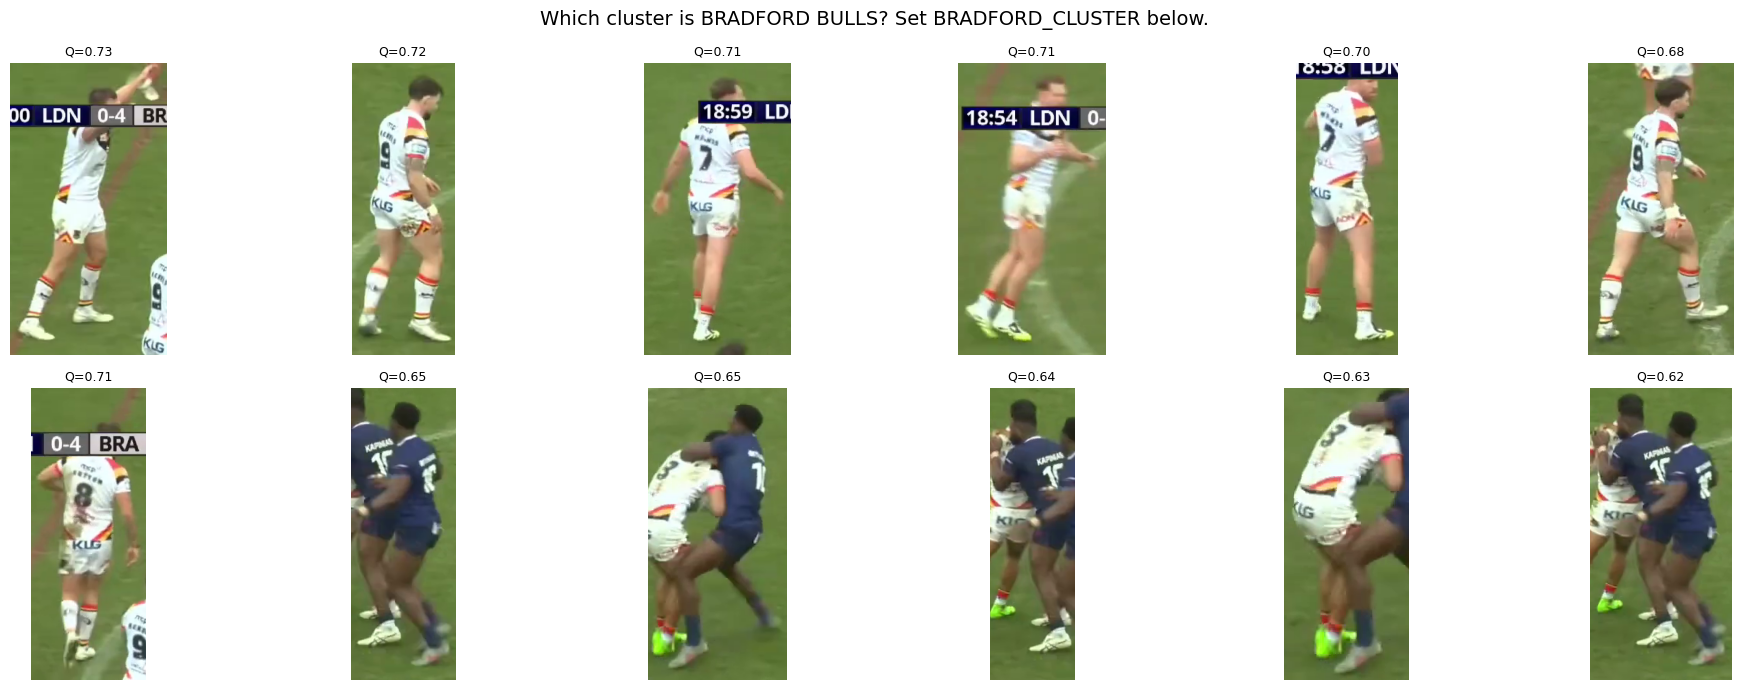

In [7]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(jersey_colors.astype(np.float32))

for i, meta in enumerate(all_crops_meta):
    meta["team_cluster"] = int(cluster_labels[i])

c0 = sum(1 for c in cluster_labels if c == 0)
c1 = sum(1 for c in cluster_labels if c == 1)
print(f"Cluster 0: {c0:,} crops")
print(f"Cluster 1: {c1:,} crops")

# Show sample crops from each cluster
cap = cv2.VideoCapture(str(VIDEO_PATH))

fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for cluster_id in [0, 1]:
    cluster_crops = [m for m in all_crops_meta if m["team_cluster"] == cluster_id]
    cluster_crops.sort(key=lambda x: x["quality"], reverse=True)
    samples = cluster_crops[:6]

    for j, meta in enumerate(samples):
        cap.set(cv2.CAP_PROP_POS_FRAMES, meta["frame_num"])
        ret, frame = cap.read()
        if not ret:
            continue
        cx1, cy1, cx2, cy2 = meta["crop_bbox"]
        crop = frame[cy1:cy2, cx1:cx2]
        axes[cluster_id][j].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        axes[cluster_id][j].set_title(f"Q={meta['quality']:.2f}", fontsize=9)
        axes[cluster_id][j].axis("off")

    axes[cluster_id][0].set_ylabel(f"Cluster {cluster_id}\n({c0 if cluster_id==0 else c1} crops)",
                                    fontsize=11, fontweight="bold")

cap.release()
plt.suptitle("Which cluster is BRADFORD BULLS? Set BRADFORD_CLUSTER below.", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# ⚠️ USER INPUT: Which cluster is Bradford Bulls?
# Look at the images above and set 0 or 1
# ============================================================
BRADFORD_CLUSTER = 0  # ← CHANGE THIS after looking at the images above

bradford_crops = [m for m in all_crops_meta if m["team_cluster"] == BRADFORD_CLUSTER]
print(f"After team filter: {len(bradford_crops):,} Bradford Bulls crops "
      f"(removed {len(all_crops_meta) - len(bradford_crops):,} opponent crops)")

After team filter: 68 Bradford Bulls crops (removed 21 opponent crops)


## 8. [L4] Quality Filter + [L5] De-duplicate + [L6] Top N Selection

In [9]:
# L4: Quality threshold
quality_filtered = [m for m in bradford_crops if m["quality"] >= MIN_QUALITY]
quality_filtered.sort(key=lambda x: x["quality"], reverse=True)
print(f"L4 quality filter (>= {MIN_QUALITY}): {len(quality_filtered):,} crops")

# L5 + L6: De-duplicate + diverse selection
cap = cv2.VideoCapture(str(VIDEO_PATH))

selected = []
selected_hashes = []
time_bucket_counts = Counter()
MAX_PER_BUCKET = max(3, TARGET_CROPS // (int(DURATION / TIME_BUCKET_SEC) + 1) + 2)

print(f"De-duplicating & selecting top {TARGET_CROPS} crops...")
print(f"  Max per {TIME_BUCKET_SEC}s bucket: {MAX_PER_BUCKET}")

for meta in tqdm(quality_filtered, desc="L5+L6: Select diverse crops"):
    bucket = int(meta["timestamp_sec"] // TIME_BUCKET_SEC)
    if time_bucket_counts[bucket] >= MAX_PER_BUCKET:
        continue

    cap.set(cv2.CAP_PROP_POS_FRAMES, meta["frame_num"])
    ret, frame = cap.read()
    if not ret:
        continue

    cx1, cy1, cx2, cy2 = meta["crop_bbox"]
    crop = frame[cy1:cy2, cx1:cx2]
    if crop.size == 0:
        continue

    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    crop_hash = imagehash.phash(Image.fromarray(crop_rgb))

    is_dup = False
    for existing_hash in selected_hashes:
        if crop_hash - existing_hash < DEDUP_HASH_THRESH:
            is_dup = True
            break
    if is_dup:
        continue

    meta["crop_hash"] = str(crop_hash)
    selected.append(meta)
    selected_hashes.append(crop_hash)
    time_bucket_counts[bucket] += 1

    if len(selected) >= TARGET_CROPS:
        break

cap.release()

print(f"\nL5+L6 complete: {len(selected)} diverse, high-quality crops selected")
if selected:
    quals = [s["quality"] for s in selected]
    print(f"Quality range: {min(quals):.3f} — {max(quals):.3f} (mean {np.mean(quals):.3f})")

L4 quality filter (>= 0.25): 68 crops
De-duplicating & selecting top 10 crops...
  Max per 30s bucket: 3


L5+L6: Select diverse crops: 100%|██████████| 68/68 [00:01<00:00, 54.29it/s]


L5+L6 complete: 3 diverse, high-quality crops selected
Quality range: 0.710 — 0.732 (mean 0.720)


## 9. Save Selected Crops + Metadata to Google Drive

In [10]:
selected.sort(key=lambda x: x["timestamp_sec"])

cap = cv2.VideoCapture(str(VIDEO_PATH))
metadata_rows = []

for idx, meta in enumerate(tqdm(selected, desc="Saving crops to Drive")):
    cap.set(cv2.CAP_PROP_POS_FRAMES, meta["frame_num"])
    ret, frame = cap.read()
    if not ret:
        continue

    cx1, cy1, cx2, cy2 = meta["crop_bbox"]
    crop = frame[cy1:cy2, cx1:cx2]

    filename = f"crop_{idx+1:04d}_{meta['timestamp_hms']}_q{meta['quality']:.2f}.jpg"
    cv2.imwrite(str(BEST_CROPS_DIR / filename), crop, [cv2.IMWRITE_JPEG_QUALITY, 95])

    meta["filename"] = filename
    metadata_rows.append({
        "crop_id": idx + 1,
        "filename": filename,
        "frame_num": meta["frame_num"],
        "timestamp_sec": meta["timestamp_sec"],
        "timestamp_hms": meta["timestamp_hms"],
        "quality": meta["quality"],
        "size_score": meta["size_score"],
        "sharpness": meta["sharpness"],
        "frontality": meta["frontality"],
        "area_pct": round(meta["area_ratio"] * 100, 2),
        "bbox": str(meta["bbox"]),
        "source_video": VIDEO_PATH.name,
    })

cap.release()

df = pd.DataFrame(metadata_rows)
csv_path = METADATA_DIR / "selected_crops_index.csv"
df.to_csv(csv_path, index=False)

print(f"\nSaved {len(metadata_rows)} crops to Google Drive:")
print(f"  Crops: {BEST_CROPS_DIR}")
print(f"  CSV:   {csv_path}")

Saving crops to Drive: 100%|██████████| 3/3 [00:02<00:00,  1.39it/s]



Saved 3 crops to Google Drive:
  Crops: /content/drive/MyDrive/Bradford_Bulls/best_crops
  CSV:   /content/drive/MyDrive/Bradford_Bulls/metadata/selected_crops_index.csv


## 10. Preview Selected Crops

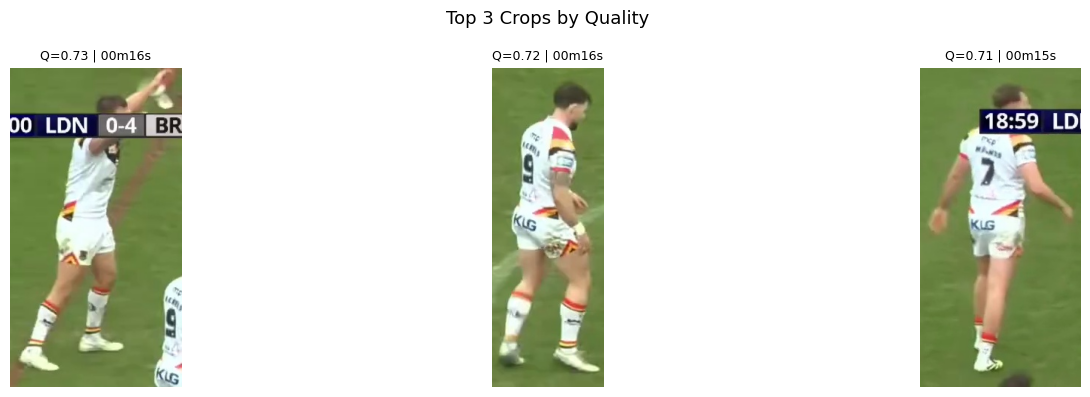

Total crops saved: 3


In [11]:
crop_files = sorted(BEST_CROPS_DIR.glob("crop_*.jpg"))

def get_quality(path):
    return float(path.stem.split("_q")[-1])

by_quality = sorted(crop_files, key=get_quality, reverse=True)

n_show = min(12, len(by_quality))
cols = min(4, n_show)
rows = (n_show + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
if n_show == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, fpath in enumerate(by_quality[:n_show]):
    img = cv2.imread(str(fpath))
    axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    q = get_quality(fpath)
    ts = fpath.stem.split("_")[2]
    axes[i].set_title(f"Q={q:.2f} | {ts}", fontsize=9)
    axes[i].axis("off")

for j in range(n_show, len(axes)):
    axes[j].axis("off")

plt.suptitle(f"Top {n_show} Crops by Quality", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Total crops saved: {len(crop_files)}")

## 11. Auto-Annotate Crops with Grounding DINO

Grounding DINO runs on **player crops** (not full frames).
Logo = 10-20% of crop → much easier to detect accurately.

In [12]:
import torchvision

gdino = load_model(GDINO_CONFIG_PATH, GDINO_WEIGHTS_PATH, device=device)
print(f"Grounding DINO loaded on {device}")

# ============================================================
# CLASS MAPPING (21 classes)
# ============================================================
CLASS_NAMES = [
    "aon_red", "aon_white", "atm_hospitality", "cch_black", "cch_white",
    "chadlaw", "em_workwear", "fairway_flooring", "klg", "mcp_away",
    "mcp_home", "mna_cladding", "mna_support", "paints_lacquers_yellow",
    "top_notch", "bartercard", "floor_tonic", "paints_lacquers_red",
    "romantica_white", "romantica_black", "acs_group",
]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

# ============================================================
# STRATEGY: Run each brand name as a SEPARATE prompt
# ============================================================
# Most logos are text-based → use actual brand name as prompt.
# Run per-brand → each detection gets the correct class.
# Then NMS removes overlapping boxes across brands.
BRAND_PROMPTS = {
    "AON":              ["aon_red", "aon_white"],  # 2 variants, classify later on Roboflow
    "ATM":              ["atm_hospitality"],
    "CCH":              ["cch_black", "cch_white"],
    "Cedar Court":      ["cch_black"],
    "ChadLaw":          ["chadlaw"],
    "EM Workwear":      ["em_workwear"],
    "Fairway":          ["fairway_flooring"],
    "KLG":              ["klg"],
    "MCP":              ["mcp_home", "mcp_away"],
    "MNA":              ["mna_cladding", "mna_support"],
    "Paints":           ["paints_lacquers_yellow", "paints_lacquers_red"],
    "Top Notch":        ["top_notch"],
    "Bartercard":       ["bartercard"],
    "Floor Tonic":      ["floor_tonic"],
    "Romantica":        ["romantica_white", "romantica_black"],
    "ACS":              ["acs_group"],
}

# Output dirs
AUTOLABEL_IMG_DIR = AUTOLABEL_DIR / "images"
AUTOLABEL_LBL_DIR = AUTOLABEL_DIR / "labels"
AUTOLABEL_IMG_DIR.mkdir(parents=True, exist_ok=True)
AUTOLABEL_LBL_DIR.mkdir(parents=True, exist_ok=True)

# Save classes.txt
classes_file = AUTOLABEL_DIR / "classes.txt"
classes_file.write_text("\n".join(CLASS_NAMES))
print(f"Saved {len(CLASS_NAMES)} classes to {classes_file}")

crop_files = sorted(BEST_CROPS_DIR.glob("crop_*.jpg"))
print(f"Processing {len(crop_files)} crops × {len(BRAND_PROMPTS)} brands...")

NMS_IOU_THRESHOLD = 0.3  # Remove boxes with IoU > 0.3

total_detections = 0
crops_with_detections = 0

for idx, crop_path in enumerate(crop_files):
    image_source, image_tensor = load_image(str(crop_path))
    h_img, w_img = image_source.shape[:2]

    # Collect all detections across all brand prompts
    all_boxes = []   # [cx, cy, w, h] normalized
    all_scores = []
    all_classes = []

    for brand_text, class_names in BRAND_PROMPTS.items():
        prompt = brand_text + " ."

        boxes, logits, phrases = predict(
            model=gdino,
            image=image_tensor,
            caption=prompt,
            box_threshold=GDINO_BOX_THRESHOLD,
            text_threshold=GDINO_TEXT_THRESHOLD,
            device=device,
        )

        if len(boxes) == 0:
            continue

        cls_idx = CLASS_TO_IDX[class_names[0]]  # primary class for this brand

        for box, score in zip(boxes, logits):
            cx, cy, w, h = box.tolist()
            # Skip boxes too large (whole person) or too tiny (noise)
            if w > 0.7 or h > 0.7 or w < 0.02 or h < 0.02:
                continue
            all_boxes.append([cx, cy, w, h])
            all_scores.append(float(score))
            all_classes.append(cls_idx)

    # Apply NMS to remove overlapping boxes
    labels = []
    if all_boxes:
        # Convert cxcywh → xyxy for NMS
        boxes_xyxy = []
        for cx, cy, w, h in all_boxes:
            x1 = (cx - w/2) * w_img
            y1 = (cy - h/2) * h_img
            x2 = (cx + w/2) * w_img
            y2 = (cy + h/2) * h_img
            boxes_xyxy.append([x1, y1, x2, y2])

        boxes_tensor = torch.tensor(boxes_xyxy, dtype=torch.float32)
        scores_tensor = torch.tensor(all_scores, dtype=torch.float32)

        keep = torchvision.ops.nms(boxes_tensor, scores_tensor, NMS_IOU_THRESHOLD)

        for k in keep:
            k = k.item()
            cx, cy, w, h = all_boxes[k]
            cls_idx = all_classes[k]
            labels.append(f"{cls_idx} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")

    # Save
    shutil.copy2(str(crop_path), str(AUTOLABEL_IMG_DIR / crop_path.name))
    lbl_path = AUTOLABEL_LBL_DIR / (crop_path.stem + ".txt")
    lbl_path.write_text("\n".join(labels) if labels else "")

    if labels:
        crops_with_detections += 1
    total_detections += len(labels)

    if (idx + 1) % 10 == 0 or idx == len(crop_files) - 1:
        print(f"  [{idx+1}/{len(crop_files)}] detections: {total_detections}")

print(f"\nDone!")
print(f"  Crops with logos: {crops_with_detections}/{len(crop_files)}")
print(f"  Total boxes: {total_detections} (avg {total_detections/max(len(crop_files),1):.1f}/crop)")
print(f"\n  Images: {AUTOLABEL_IMG_DIR}")
print(f"  Labels: {AUTOLABEL_LBL_DIR}")

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


final text_encoder_type: bert-base-uncased


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Grounding DINO loaded on cuda
Saved 21 classes to /content/drive/MyDrive/Bradford_Bulls/auto_annotated_crops/classes.txt
Processing 3 crops × 16 brands...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:993: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
/usr/local/lib/python3.12/dist-packages/groundingdino/models/GroundingDINO/transformer.py:862: FutureWarning: `torch.cuda.amp.autocast(args

  [3/3] detections: 16

Done!
  Crops with logos: 3/3
  Total boxes: 16 (avg 5.3/crop)

  Images: /content/drive/MyDrive/Bradford_Bulls/auto_annotated_crops/images
  Labels: /content/drive/MyDrive/Bradford_Bulls/auto_annotated_crops/labels


## 12. Preview Auto-Annotations

Auto-annotated crops: 3

Detections per class:
   0 aon_red                      1
   3 cch_black                    2
   6 em_workwear                  3
   8 klg                          3
  13 paints_lacquers_yellow       2
  14 top_notch                    1
  16 floor_tonic                  3
  20 acs_group                    1
  TOTAL                          16


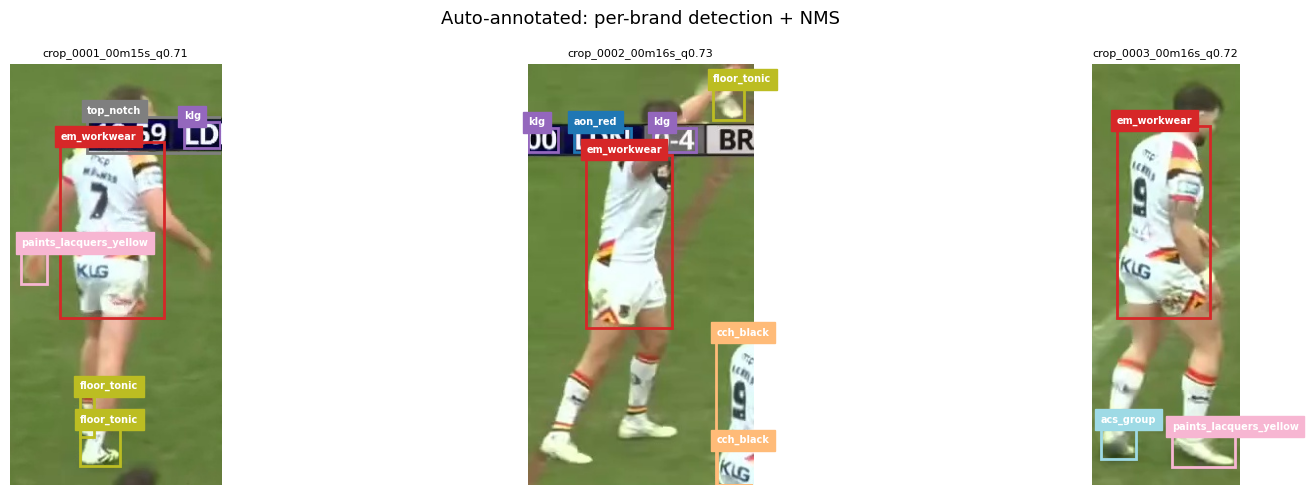

In [13]:
img_dir = AUTOLABEL_DIR / "images"
lbl_dir = AUTOLABEL_DIR / "labels"

annotated_imgs = sorted(img_dir.glob("*.jpg"))
print(f"Auto-annotated crops: {len(annotated_imgs)}")

# Count detections per class
from collections import Counter
class_counts = Counter()
for lbl_path in sorted(lbl_dir.glob("*.txt")):
    text = lbl_path.read_text().strip()
    if not text:
        continue
    for line in text.split("\n"):
        cls_id = int(line.split()[0])
        class_counts[cls_id] += 1

print("\nDetections per class:")
for cls_id in sorted(class_counts):
    name = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else f"cls_{cls_id}"
    print(f"  {cls_id:2d} {name:25s} {class_counts[cls_id]:4d}")
print(f"  {'TOTAL':28s} {sum(class_counts.values()):4d}")

# Visualize
n_show = min(8, len(annotated_imgs))
cols = min(4, n_show)
rows = max(1, (n_show + cols - 1) // cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
if n_show <= 1:
    axes = np.array([axes]).flatten()
else:
    axes = axes.flatten()

sample_step = max(1, len(annotated_imgs) // n_show)
samples = [annotated_imgs[i * sample_step] for i in range(n_show) if i * sample_step < len(annotated_imgs)]

cmap = plt.cm.tab20(np.linspace(0, 1, len(CLASS_NAMES)))

for ax_idx, img_path in enumerate(samples):
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    axes[ax_idx].imshow(img_rgb)

    lbl_path = lbl_dir / (img_path.stem + ".txt")
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().split("\n"):
            if not line.strip():
                continue
            parts = line.strip().split()
            cls_id = int(parts[0])
            cx, cy, bw, bh = [float(x) for x in parts[1:5]]
            rx = (cx - bw/2) * w
            ry = (cy - bh/2) * h
            rw, rh = bw * w, bh * h
            label = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else f"cls_{cls_id}"
            color = cmap[cls_id % len(cmap)]
            rect = patches.Rectangle((rx, ry), rw, rh, linewidth=2,
                                     edgecolor=color, facecolor='none')
            axes[ax_idx].add_patch(rect)
            axes[ax_idx].text(rx, ry - 3, label, color='white', fontsize=7,
                             fontweight='bold', backgroundcolor=color[:3])

    axes[ax_idx].set_title(img_path.stem[:25], fontsize=8)
    axes[ax_idx].axis("off")

for j in range(len(samples), len(axes)):
    axes[j].axis("off")

plt.suptitle("Auto-annotated: per-brand detection + NMS", fontsize=13)
plt.tight_layout()
plt.show()

## 13. Upload to Roboflow

In [14]:
from roboflow import Roboflow

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
workspace = rf.workspace()

try:
    project = workspace.project(PROJECT_NAME)
    print(f"Connected to existing project: {project.name}")
except Exception:
    project = workspace.create_project(
        project_name="Kit Sponsor Logos",
        project_type="object-detection",
        project_license="MIT",
        annotation="kit-sponsor-logos",
    )
    print("Created new project: Kit Sponsor Logos")

img_dir = AUTOLABEL_DIR / "images"
lbl_dir = AUTOLABEL_DIR / "labels"

annotated_imgs = sorted(img_dir.glob("*.jpg"))
success, errors = 0, 0

for img_path in tqdm(annotated_imgs, desc="Uploading to Roboflow"):
    lbl_path = lbl_dir / (img_path.stem + ".txt")
    try:
        if lbl_path.exists() and lbl_path.read_text().strip():
            project.upload(image_path=str(img_path), annotation_path=str(lbl_path), split="train")
        else:
            project.upload(image_path=str(img_path), split="train")
        success += 1
    except Exception as e:
        errors += 1
        if errors <= 3:
            print(f"  Error: {e}")

print(f"\nDone! Success: {success} | Errors: {errors}")
print(f"Review annotations: https://app.roboflow.com/{workspace.url}/{PROJECT_NAME}/annotate")

loading Roboflow workspace...
loading Roboflow project...
Connected to existing project: kit-sponsor-logos


Uploading to Roboflow: 100%|██████████| 3/3 [00:03<00:00,  1.15s/it]


Done! Success: 3 | Errors: 0
Review annotations: https://app.roboflow.com/bradford-bulls/kit-sponsor-logos/annotate


## 14. Summary

### Pipeline Results
```
Video → L1 temporal sample → L2 detect+crop → L3 team filter
    → L4 quality → L5 de-dup → L6 top N → Grounding DINO annotate
    → Upload to Roboflow for review
```

### Output on Google Drive (`/content/drive/MyDrive/Bradford_Bulls/`)
```
Bradford_Bulls/
├── videos/                     ← Source video
├── best_crops/                 ← Final selected player crops
├── metadata/                   ← CSV with crop metadata
├── auto_annotated_crops/       ← Grounding DINO labels
│   ├── images/
│   └── labels/
└── (Roboflow)                  ← Review & correct annotations online
```

### Next Steps
1. Review annotations on Roboflow — correct any wrong/missing labels
2. Export YOLO format dataset from Roboflow
3. Train YOLOv8 model on annotated crops (Phase 2)